## Importing necessary libraries

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sqlite3

df_m = pd.read_csv("../data_files/executions.csv")
df_h = pd.read_csv("../data_files/historical_execution_data.txt")

## Cleaning historical execution dataset

In [54]:
df_h.head()

,V5,V6,V7,V10,V11,V12,V13,V14,V16,V19,V21
0,1,,NORMAN ELI,1,1,19,12,1812,1,1,250
1,1,,WOODS JOHN,44,4,6,2,1814,1,1,616
2,2,,GAMARRA CHARLES,13,1,19,5,1820,1,1,
3,2,,DESAYAS VICTORIANO,1,1,19,5,1820,1,1,
4,2,,NOREAGO FRANCISCO,1,1,30,5,1822,1,1,187


In [55]:
col_to_move = df_h.pop('V19')
df_h.insert(1, 'V19', col_to_move)

In [56]:
df_h.columns = ['race', 'sex', 'age', 'name', 'crime_com', 'exec_method', 'date_day', 'date_month', 'date_year', 'state', 'off_occ']

In [57]:
df_h = df_h.sort_values(by='date_year')

#### Assigning correct data types and code names

In [58]:
df_h['age'] = pd.to_numeric(df_h['age'], errors='coerce').fillna(0).astype(int)
df_h['race'] = df_h['race'].replace({
    '1': 'White',
    '2': 'Black',
    '3': 'Native Am',
    '4': 'Asian-Pac-Il',
    '5': 'Hispanic',
    '6': 'Other',
    ' ': 'Unknown'
    })
df_h['sex'] = df_h['sex'].replace({'1': 'Male', '2': 'Female', ' ': 'Unknown'})

In [59]:
df_h['crime_com'] = df_h['crime_com'].str.strip()
df_h['crime_com'] = df_h['crime_com'].replace({
    '1': 'Murder',
    '2': 'Rape',
    '3': 'Criminal Assault',
    '4': 'HouseBrkng-Burgl',
    '5': 'Horse Stealing',
    '6': 'Consp to Murder',
    '7': 'Treason',
    '8': 'Slave Revolt',
    '9': 'Witchcraft',
    '10': 'Robbery-Murder',
    '11': 'Rape-Murder',
    '12': 'Piracy',
    '13': 'Accessory to Mur',
    '14': 'Desertion',
    '15': 'Robbery',
    '16': 'Arson',
    '17': 'Guerilla Activity',
    '18': 'Spying-Espionage',
    '19': 'Murder-Rape-Rob',
    '20': 'Burg-Att Rape',
    '21': 'Rioting',
    '22': 'Attempted Rape',
    '23': 'Murder-Burglary',
    '24': 'Kidnap-Murder',
    '25': 'Kidnap-Murder-Rob',
    '26': 'Arson-Murder',
    '27': 'Rape-Robbery',
    '28': 'Kidnapping',
    '29': 'Prisn Brk-Kidnap',
    '30': 'Sodmy-Buggry-Bst',
    '31': 'Adultery',
    '33': 'Poisoning',
    '35': 'Concealing Birth',
    '36': 'Unspec Felony',
    '37': 'Aid Runaway Slave',
    '39': 'Counterfeiting',
    '40': 'Attempted Murder',
    '41': 'Forgery',
    '43': 'Theft-Stealing',
    '44': 'Other',
    '': 'Unknown',
})

In [60]:
df_h['exec_method'] = df_h['exec_method'].str.strip()
df_h['exec_method'] = df_h['exec_method'].replace({
    '1': 'Hanging',
    '2': 'Electrocution',
    '3': 'Asphyxiation-Gas',
    '4': 'Shot',
    '5': 'Injection',
    '6': 'Pressing',
    '8': 'Break on Wheel',
    '10': 'Burned',
    '11': 'Hung in Chains',
    '13': 'Bludgeoned',
    '14': 'Gibbetted',
    '15': 'Other',
    '': 'Unknown'
})

In [61]:
df_h['off_occ'] = df_h['off_occ'].str.strip()
df_h['off_occ'] = df_h['off_occ'].replace({
    '610': 'Slave',
    '355': 'Laborer',
    '236': 'Farm Hand',
    '241': 'Farmer',
    '160': 'Convict',
    '224': 'Ex Convict',
    '237': 'Farm Laborer',
    '465': 'Parolee',
    '417': 'Miner',
    '616': 'Soldier',
    '272': 'Gangster',
    '220': 'Escaped Convict',
    '591': 'Seaman',
    '173': 'Criminal',
    '475': 'Pirate',
    '654': 'Tenant Farmer',
    '271': 'Gang Member',
    '108': 'Carpenter',
    '328': 'Housewife',
    '689': 'Truck Driver',
    '530': 'Railroad Worker',
    '259': 'Freedman',
    '': 'Unknown'})

In [62]:
df_h['state'] = df_h['state'].astype(str)
df_h['state'] = df_h['state'].replace({
'1': 'Alabama',
'2': 'Alaska',
'4': 'Arizona',
'5': 'Arkansas',
'6': 'California',
'8': 'Colorado',
'9': 'Connecticut',
'10': 'Delaware',
'11': 'Washington, D.C.',
'12': 'Florida',
'13': 'Georgia',
'15': 'Hawaii',
'16': 'Idaho',
'17': 'Illinois',
'18': 'Indiana',
'19': 'Iowa',
'20': 'Kansas',
'21': 'Kentucky',
'22': 'Louisiana',
'23': 'Maine',
'24': 'Maryland',
'25': 'Massachusetts',
'26': 'Michigan',
'27': 'Minnesota',
'28': 'Mississippi',
'29': 'Missouri',
'30': 'Montana',
'31': 'Nebraska',
'32': 'Nevada',
'33': 'New Hampshire',
'34': 'New Jersey',
'35': 'New Mexico',
'36': 'New York',
'37': 'North Carolina',
'38': 'North Dakota',
'39': 'Ohio',
'40': 'Oklahoma',
'41': 'Oregon',
'42': 'Pennsylvania',
'44': 'Rhode Island',
'45': 'South Carolina',
'46': 'South Dakota',
'47': 'Tennessee',
'48': 'Texas',
'49': 'Utah',
'50': 'Vermont',
'51': 'Virginia',
'53': 'Washington',
'54': 'West Virginia',
'55': 'Wisconsin',
'56': 'Wyoming'})

#### Creating pre-1977 variable for historical data to prevent overlap during concatenation with modern dataset.

In [63]:
df_h_pre1977 = df_h[df_h['date_year'] < 1977]
df_h_pre1977.tail()

,race,sex,age,name,crime_com,exec_method,date_day,date_month,date_year,state,off_occ
4388,White,Male,23,YORK GEORGE,Robbery-Murder,Hanging,22,6,1965,Kansas,Soldier
707,White,Male,33,BOWEN WILLIAM JR,Murder,Electrocution,15,1,1965,Alabama,467
9987,White,Male,30,FRENCH JAMES,Murder,Electrocution,10,8,1966,Oklahoma,Convict
2120,Hispanic,Male,48,MONGE LUIS,Murder,Asphyxiation-Gas,2,6,1967,Colorado,12
2019,Black,Male,37,MITCHELL AARON,Murder,Asphyxiation-Gas,12,4,1967,California,460


## Cleaning modern execution dataset

In [64]:
df_m = df_m.drop(columns=['Number of White Male Victims',
       'Number of Black Male Victims', 'Number of Latino Male Victims',
       'Number of Asian Male Victims',
       'Number of Native American Male Victims',
       'Number of Other Race Male Victims', 'Number of White Female Victims',
       'Number of Black Female Victims', 'Number of Latino Female Victims',
       'Number of Asian Female Victims',
       'Number of American Indian or Alaska Native Female Victims',
       'Number of Other Race Female Victims', 'Victim Races Includes White'])

In [65]:
df_m.rename(columns={'Number of Victims': 'num_vics',
                     'Number of Male Victims': 'num_male_vics',
                     'Number of Female Victims': 'num_female_vics'}, inplace=True)

df_m['Race'] = df_m['Race'].replace({'Other Race': 'Other'})
df_m['Victim Races'] = df_m['Victim Races'].replace({'Other Race': 'Other'})

In [66]:
col_to_move = df_m.pop('Middle Name(s)')
df_m.insert(1, 'Middle Name(s)', col_to_move)
df_m.head()

,First Name,Middle Name(s),Last Name,Suffix,Race,Sex,Age,Foreign National,Juvenile,Federal,...,Country,State,County,Execution Date,Method,Victims,Victim Races,num_vics,num_male_vics,num_female_vics
0,Gary,Mark,Gilmore,NaN,White,Male,36,No,No,No,...,United States,Utah,Utah County,01/17/1977,Firing Squad,1 White Male,White,1,1,0
1,John,NaN,Spenkelink,NaN,White,Male,30,No,No,No,...,United States,Florida,Leon County,05/25/1979,Electrocution,1 White Male,White,1,1,0
2,Jesse,NaN,Bishop,NaN,White,Male,46,No,No,No,...,United States,Nevada,Clark County,10/22/1979,Gas,1 White Male,White,1,1,0
3,Steven,Timothy,Judy,NaN,White,Male,24,No,No,No,...,United States,Indiana,Morgan County,03/09/1981,Electrocution,"2 White Females, 2 White Males",White,4,2,2
4,Frank,NaN,Coppola,NaN,White,Male,38,No,No,No,...,United States,Virginia,Newport News city,08/10/1982,Electrocution,1 White Male,White,1,1,0


#### Standardizing dates in both datasets

In [67]:
# AI-assisted code
df_h['execution_date'] = pd.to_datetime(
    {'year': df_h['date_year'], 'month': df_h['date_month'], 'day': df_h['date_day']},
    errors='coerce')

In [68]:
df_h.head()

,race,sex,age,name,crime_com,exec_method,date_day,date_month,date_year,state,off_occ,execution_date
13062,White,Male,0,KENDALL GEORGE,Spying-Espionage,Shot,,,1608,Virginia,166,NaT
13063,White,Male,0,FRANK DANIELL,Theft-Stealing,Hanging,1,3,1622,Virginia,331,1622-03-01
13064,White,Male,0,CORNISH RICHARD,Sodmy-Buggry-Bst,Hanging,,,1624,Virginia,Unknown,NaT
13065,White,Male,21,HAYLE THOMAS,Rape,Hanging,6,,1626,Virginia,Unknown,NaT
5795,White,Male,40,BILLINGTON JOHN,Murder,Hanging,30,9,1630,Massachusetts,Unknown,1630-09-30


In [69]:
df_h['execution_date'].dtype

dtype('<M8[us]')

In [70]:
# AI-assisted code
df_m['Execution Date'] = pd.to_datetime(df_m['Execution Date'])
df_m['year'] = df_m['Execution Date'].dt.year

In [71]:
df_m.head()

,First Name,Middle Name(s),Last Name,Suffix,Race,Sex,Age,Foreign National,Juvenile,Federal,...,State,County,Execution Date,Method,Victims,Victim Races,num_vics,num_male_vics,num_female_vics,year
0,Gary,Mark,Gilmore,NaN,White,Male,36,No,No,No,...,Utah,Utah County,1977-01-17,Firing Squad,1 White Male,White,1,1,0,1977
1,John,NaN,Spenkelink,NaN,White,Male,30,No,No,No,...,Florida,Leon County,1979-05-25,Electrocution,1 White Male,White,1,1,0,1979
2,Jesse,NaN,Bishop,NaN,White,Male,46,No,No,No,...,Nevada,Clark County,1979-10-22,Gas,1 White Male,White,1,1,0,1979
3,Steven,Timothy,Judy,NaN,White,Male,24,No,No,No,...,Indiana,Morgan County,1981-03-09,Electrocution,"2 White Females, 2 White Males",White,4,2,2,1981
4,Frank,NaN,Coppola,NaN,White,Male,38,No,No,No,...,Virginia,Newport News city,1982-08-10,Electrocution,1 White Male,White,1,1,0,1982


In [72]:
df_m['Execution Date'].dtype

dtype('<M8[us]')

In [73]:
col_to_move2 = df_m.pop('year')
df_m.insert(15, 'year', col_to_move2)

df_m.head()

,First Name,Middle Name(s),Last Name,Suffix,Race,Sex,Age,Foreign National,Juvenile,Federal,...,State,County,Execution Date,year,Method,Victims,Victim Races,num_vics,num_male_vics,num_female_vics
0,Gary,Mark,Gilmore,NaN,White,Male,36,No,No,No,...,Utah,Utah County,1977-01-17,1977,Firing Squad,1 White Male,White,1,1,0
1,John,NaN,Spenkelink,NaN,White,Male,30,No,No,No,...,Florida,Leon County,1979-05-25,1979,Electrocution,1 White Male,White,1,1,0
2,Jesse,NaN,Bishop,NaN,White,Male,46,No,No,No,...,Nevada,Clark County,1979-10-22,1979,Gas,1 White Male,White,1,1,0
3,Steven,Timothy,Judy,NaN,White,Male,24,No,No,No,...,Indiana,Morgan County,1981-03-09,1981,Electrocution,"2 White Females, 2 White Males",White,4,2,2
4,Frank,NaN,Coppola,NaN,White,Male,38,No,No,No,...,Virginia,Newport News city,1982-08-10,1982,Electrocution,1 White Male,White,1,1,0


## Creating SQL Schemas

In [74]:
# AI-assisted code
# Make updated dataframes, include ALL columns for both datasets, make irrelevant columns NULL,
# then combine into one dataframe.

historical_data = pd.DataFrame({
    'race': df_h_pre1977['race'],
    'sex': df_h_pre1977['sex'],
    'age': df_h_pre1977['age'],
    'crime_com': df_h_pre1977['crime_com'],
    'exec_method': df_h_pre1977['exec_method'],
    'date_year': df_h_pre1977['date_year'],
    'state': df_h_pre1977['state'],
    'off_occ': df_h_pre1977['off_occ'],
    'foreign_national': pd.NA,
    'juvenile': pd.NA,
    'federal': pd.NA,
    'region': pd.NA,
    'victims': pd.NA,
    'victim_races': pd.NA,
    'num_vics': pd.NA,
    'num_male_vics': pd.NA,
    'num_female_vics': pd.NA,
    })

modern_data = pd.DataFrame({
    'race': df_m['Race'],
    'sex': df_m['Sex'],
    'age': df_m['Age'],
    'crime_com': pd.NA,
    'exec_method': df_m['Method'],
    'date_year': df_m['year'],
    'state': df_m['State'],
    'off_occ': pd.NA,
    'foreign_national': df_m['Foreign National'],
    'juvenile': df_m['Juvenile'],
    'federal': df_m['Federal'],
    'region': df_m['Region'],
    'victims': df_m['Victims'],
    'victim_races': df_m['Victim Races'],
    'num_vics': df_m['num_vics'],
    'num_male_vics': df_m['num_male_vics'],
    'num_female_vics': df_m['num_female_vics']
    })

# concatenating data, ignoring original index and creating a new one.

all_data = pd.concat([historical_data, modern_data], ignore_index=True)

#### SQL Table Creation Function

In [75]:
# AI-assisted code
def create_sql_lookup_table(dataframe, category_column, id_column):
    lookup_df = dataframe[[category_column]].dropna().drop_duplicates().reset_index(drop=True)
    lookup_df.insert(0, id_column, range(1, len(lookup_df) + 1))
    merged_df = dataframe.merge(lookup_df, on=category_column, how='left')
    return lookup_df, merged_df

In [76]:
# AI-assisted code
# Creating IDs for all PKs and creating dataframes.

all_data.insert(0, 'executed_inmate_id', range(1, len(all_data) + 1))
all_data.insert(0, 'execution_id', range(1, len(all_data) + 1))

exec_methods_df = all_data[['exec_method']].dropna().drop_duplicates().reset_index(drop=True)
exec_methods_df.insert(0, 'exec_method_id', range(1, len(exec_methods_df) + 1))
all_data = all_data.merge(exec_methods_df, on='exec_method', how='left')

off_occ_df, all_data = create_sql_lookup_table(all_data, 'off_occ', 'off_occ_id')

crime_com_df, all_data = create_sql_lookup_table(all_data, 'crime_com', 'crime_com_id')

executed_inmates_df = all_data[[
    'executed_inmate_id',
    'race',
    'sex',
    'victims',
    'victim_races',
    'num_vics',
    'num_male_vics',
    'num_female_vics',
    'foreign_national',
    'juvenile',
    'federal',
    'off_occ_id',
    'crime_com_id',
]]

executions_df = all_data[[
    'execution_id',
    'executed_inmate_id',
    'exec_method_id',
    'date_year',
    'state',
    'age',
    'region',
]]

In [77]:
conn = sqlite3.connect("../data_files/executions_data_combined.db")

executed_inmates_df.to_sql('executed_inmates', conn, if_exists='replace', index=False)
executions_df.to_sql('executions', conn, if_exists='replace', index=False)
exec_methods_df.to_sql('execution_methods', conn, if_exists='replace', index=False)
off_occ_df.to_sql('offender_occupations', conn, if_exists='replace', index=False)
crime_com_df.to_sql('crime_com', conn, if_exists='replace', index=False)

41

### Begin SQL Queries

In [78]:
# AI-assisted code
# occupation by race

query1 = """
with occupation_percent as (
select race, off_occ, count(*) as num_executions,
    round(count(*) * 100.0 / sum(count(*)) over (), 2) as percentage
from executed_inmates ei
join offender_occupations oo on ei.off_occ_id = oo.off_occ_id
where off_occ is not null
    and off_occ != 'Unknown'
    and trim(off_occ) glob '*[^0-9]*'
    and race != 'Unknown'
group by race, off_occ
)
select * from occupation_percent
where percentage > 2
order by num_executions desc
"""

result1 = pd.read_sql(query1, conn)
result1

,race,off_occ,num_executions,percentage
0,Black,Slave,1720,37.02
1,White,Farmer,311,6.69
2,Black,Laborer,262,5.64
3,White,Laborer,218,4.69
4,Black,Farm Hand,217,4.67
5,White,Farm Hand,135,2.91
6,White,Ex Convict,119,2.56
7,White,Convict,115,2.48
8,White,Miner,104,2.24
9,Black,Farm Laborer,101,2.17


In [79]:
# female-specific occupations and crimes committed

query2 = """
select
    sex, off_occ, crime_com, count(*) as num_executions,
    round(count(*) * 100.0 / sum(count(*)) over (), 2) as percentage
from executed_inmates ei
join offender_occupations oo on ei.off_occ_id = oo.off_occ_id
join crime_com cc on ei.crime_com_id = cc.crime_com_id
where off_occ is not null
    and off_occ != 'Unknown'
    and crime_com != 'Unknown'
    and trim(off_occ) glob '*[^0-9]*'
    and sex != 'Unknown'
    and sex != 'Male'
group by sex, crime_com, off_occ
order by num_executions desc
"""

result2 = pd.read_sql(query2, conn)
result2

,sex,off_occ,crime_com,num_executions,percentage
0,Female,Slave,Murder,93,47.21
1,Female,Housewife,Murder,29,14.72
2,Female,Slave,Arson,19,9.64
3,Female,Slave,Poisoning,12,6.09
4,Female,Housewife,Witchcraft,11,5.58
5,Female,Slave,Attempted Murder,8,4.06
6,Female,Slave,Unspec Felony,5,2.54
7,Female,Housewife,Robbery-Murder,4,2.03
8,Female,Housewife,Consp to Murder,3,1.52
9,Female,Slave,Slave Revolt,3,1.52


In [80]:
# AI-assisted code
# State-specific execution percentages by race

query3 = """
select
    state, race, count(*) as num_executions,
    round(count(*) * 100.0 / sum(count(*)) over (partition by state), 2) as percentage
from executions e
join executed_inmates ei on e.executed_inmate_id = ei.executed_inmate_id
where race != 'Unknown'
group by state, race
order by state, num_executions desc
"""

result3 = pd.read_sql(query3, conn)
result3

,state,race,num_executions,percentage
0,Alabama,Black,642,81.68
1,Alabama,White,133,16.92
2,Alabama,Native Am,11,1.40
3,Alaska,Native Am,6,50.00
4,Alaska,White,4,33.33
...,...,...,...,...
193,Wyoming,White,15,71.43
194,Wyoming,Asian-Pac-Il,2,9.52
195,Wyoming,Black,2,9.52
196,Wyoming,Hispanic,1,4.76


In [81]:
# Race of inmates vs race of victims

query4 = """
select race, victim_races, count(*) as num_executions,
    round(count(*) * 100.0 / sum(count(*)) over (), 2) as percentage
from executed_inmates ei
where race is not null
    and victim_races is not null
    and race != 'Unknown'
    and victim_races != 'Unknown'
group by race, victim_races
"""

result4 = pd.read_sql(query4, conn)
result4

,race,victim_races,num_executions,percentage
0,American Indian or Alaska Native,American Indian or Alaska Native,4,0.24
1,American Indian or Alaska Native,"Black, White",1,0.06
2,American Indian or Alaska Native,Latino/a,2,0.12
3,American Indian or Alaska Native,White,14,0.84
4,Asian,Asian,4,0.24
5,Asian,White,2,0.12
6,Black,Asian,13,0.78
7,Black,"Asian, White",1,0.06
8,Black,Black,194,11.70
9,Black,"Black, Asian",1,0.06


In [83]:
# Total number of executed inmates by race
query5 = """
select race, count(distinct ei.executed_inmate_id) as num_executions,
    round(count(*) * 100.0 / sum(count(*)) over (), 2) as percentage
from executed_inmates ei
where race is not null and race != 'Unknown'
group by race
order by num_executions desc
"""
result5 = pd.read_sql(query5, conn)
result5

,race,num_executions,percentage
0,Black,7647,49.54
1,White,6833,44.26
2,Native Am,353,2.29
3,Hispanic,295,1.91
4,Asian-Pac-Il,142,0.92
5,Latino/a,135,0.87
6,American Indian or Alaska Native,21,0.14
7,Asian,6,0.04
8,Other,5,0.03


In [ ]:
# State execution numbers and percents
query6 = """
select state, count(distinct e.execution_id) as num_executions,
    round(count(*) * 100.0 / sum(count(*)) over (), 2) as percentage
from executions e
group by state
order by num_executions desc
"""
results6 = pd.read_sql(query6, conn)
results6

,state,num_executions,percentage
0,Virginia,1391,8.61
1,Texas,1359,8.42
2,New York,1130,7.00
3,Pennsylvania,1043,6.46
4,Georgia,1028,6.37
5,North Carolina,827,5.12
6,Alabama,791,4.90
7,California,722,4.47
8,South Carolina,691,4.28
9,Louisiana,661,4.09


### Function for Categorical Analysis

In [ ]:
# AI-assisted code
def category_analysis (dataframe, column_name):
    counts = dataframe[column_name].value_counts()
    percentages = (counts / counts.sum() * 100)
    cat_analysis_df = pd.DataFrame({'Count': counts, 'Percentage': percentages})
    return cat_analysis_df

In [ ]:
category_analysis(df_m, 'Victim Races')

,Count,Percentage
Victim Races,,
White,1252,75.421687
Black,218,13.132530
Latino/a,104,6.265060
Asian,24,1.445783
"Black, White",18,1.084337
"White, Latino/a",12,0.722892
"White, Black",7,0.421687
American Indian or Alaska Native,6,0.361446
"Latino/a, White",5,0.301205


In [ ]:
category_analysis(df_h, 'crime_com')

,Count,Percentage
crime_com,,
Murder,8577,56.176316
Robbery-Murder,2670,17.487556
Rape,947,6.202515
Rape-Murder,472,3.091433
Unknown,436,2.855646
Slave Revolt,277,1.814252
HouseBrkng-Burgl,251,1.643961
Murder-Burglary,174,1.139638
Robbery,158,1.034844


In [ ]:
category_analysis(all_data, 'exec_method')

,Count,Percentage
exec_method,,
Hanging,9322,57.724937
Electrocution,4445,27.524924
Lethal Injection,1470,9.102731
Asphyxiation-Gas,582,3.603938
Shot,141,0.873119
Burned,66,0.408694
Unknown,43,0.266270
Other,24,0.148616
Gas,19,0.117654


In [ ]:
off_occ_clean = df_h.drop(df_h[df_h['off_occ'] == 'Unknown'].index)
category_analysis(off_occ_clean, 'off_occ').head(20)

,Count,Percentage
off_occ,,
Slave,1749,23.150232
Laborer,586,7.756453
Farm Hand,370,4.897419
Farmer,348,4.606221
Convict,226,2.991396
Ex Convict,197,2.607545
Farm Laborer,169,2.236929
Parolee,163,2.157512
Miner,131,1.733951


## Visualizations

#### Function for Visualization Formatting

In [ ]:
# AI-assisted code
def viz_format(title='', xlabel='', ylabel=''):
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

In [ ]:
years_combined = pd.concat([df_h_pre1977['date_year'], df_m['year']])
execution_trend = years_combined.value_counts().sort_index()

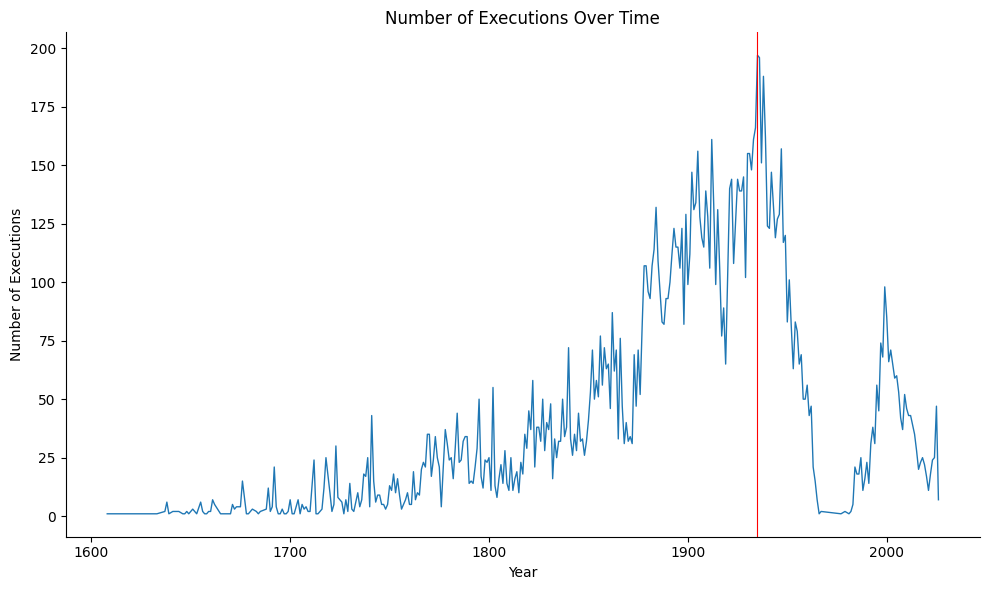

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(
    execution_trend.index,
    execution_trend.values,
    linewidth = .99)

plt.xlabel('Year')
plt.ylabel('Number of Executions')
plt.title('Number of Executions Over Time')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axvline(
    1935,
    color = "red",
    linewidth = .8
)

plt.tight_layout()
plt.show()

In [ ]:
df_h_age_clean = df_h_pre1977.drop(df_h_pre1977[df_h_pre1977['age'] == 0].index)
df_h_age_clean.head()

,race,sex,age,name,crime_com,exec_method,date_day,date_month,date_year,state,off_occ
13065,White,Male,21,HAYLE THOMAS,Rape,Hanging,6,,1626,Virginia,Unknown
5795,White,Male,40,BILLINGTON JOHN,Murder,Hanging,30,9,1630,Massachusetts,Unknown
5802,White,Male,18,HACKETT WILLIAM,Sodmy-Buggry-Bst,Hanging,10,12,1641,Massachusetts,593
5803,White,Male,17,GRAUNGER THOMAS,Sodmy-Buggry-Bst,Hanging,,,1642,Massachusetts,593
5805,White,Female,18,LATHAM MARY,Adultery,Hanging,21,3,1643,Massachusetts,Housewife


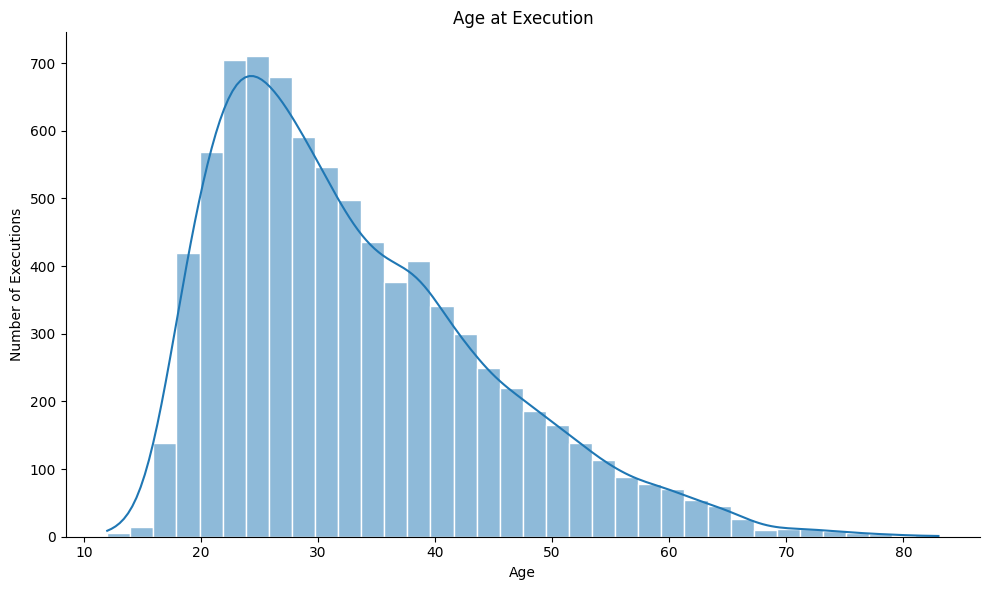

In [ ]:
age_combined = pd.concat([df_h_age_clean['age'], df_m['Age']])

plt.figure(figsize=(10,6))
sns.histplot(
    age_combined,
    edgecolor = "white",
    bins = 36,
    kde=True
)

viz_format(title='Age at Execution', xlabel='Age', ylabel='Number of Executions')
plt.show()

In [ ]:
age_combined.describe()

count    8221.000000
mean       33.046223
std        11.516498
min        12.000000
25%        24.000000
50%        30.000000
75%        40.000000
max        83.000000
dtype: float64

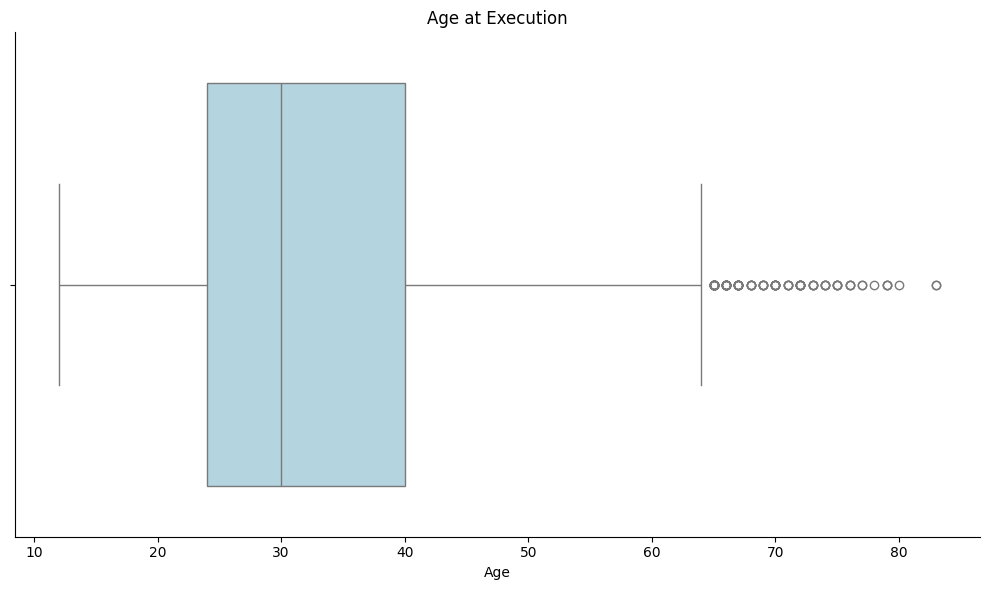

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x=age_combined,
    color="lightblue"
)

viz_format(title='Age at Execution', xlabel='Age')
plt.show()

In [ ]:
methods_combined = pd.concat([
    df_h_pre1977[['date_year', 'exec_method']].rename(columns={'date_year': 'year', 'exec_method': 'method'}),
    df_m[['year', 'Method']].rename(columns={'Method': 'method'})], ignore_index=True)
method_counts_combo = methods_combined['method'].value_counts().sort_values(ascending=False)

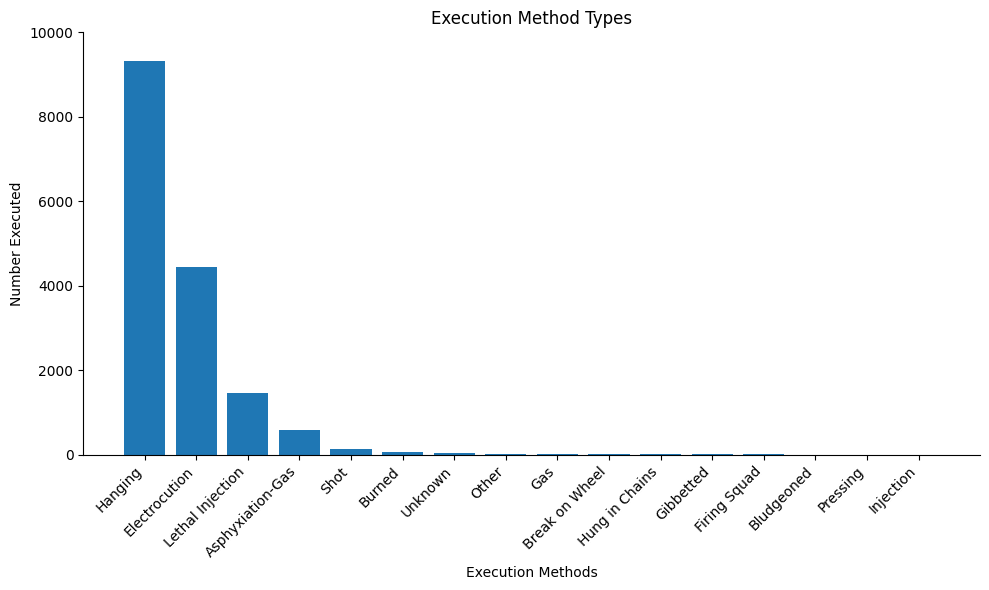

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(method_counts_combo.index, method_counts_combo.values)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 10000)

viz_format(title='Execution Method Types', xlabel='Execution Methods', ylabel='Number Executed')
plt.show()

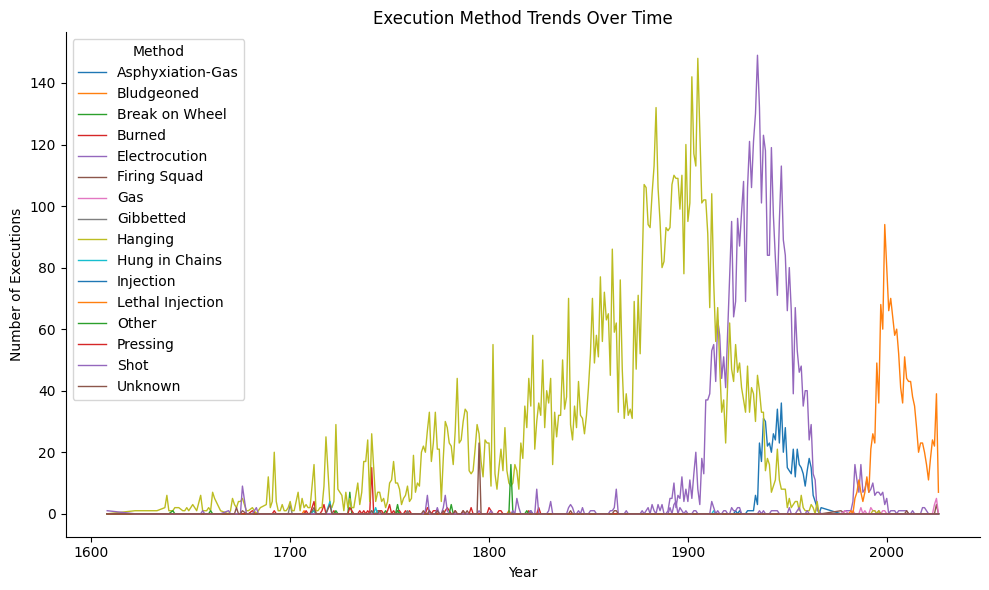

In [ ]:
# AI-assisted code
method_trends = methods_combined.groupby(['year', 'method']).size().unstack(fill_value=0).sort_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=method_trends, palette="tab10", linewidth=1, dashes=False)
plt.legend(title='Method')

viz_format(title='Execution Method Trends Over Time', xlabel='Year', ylabel='Number of Executions')
plt.show()

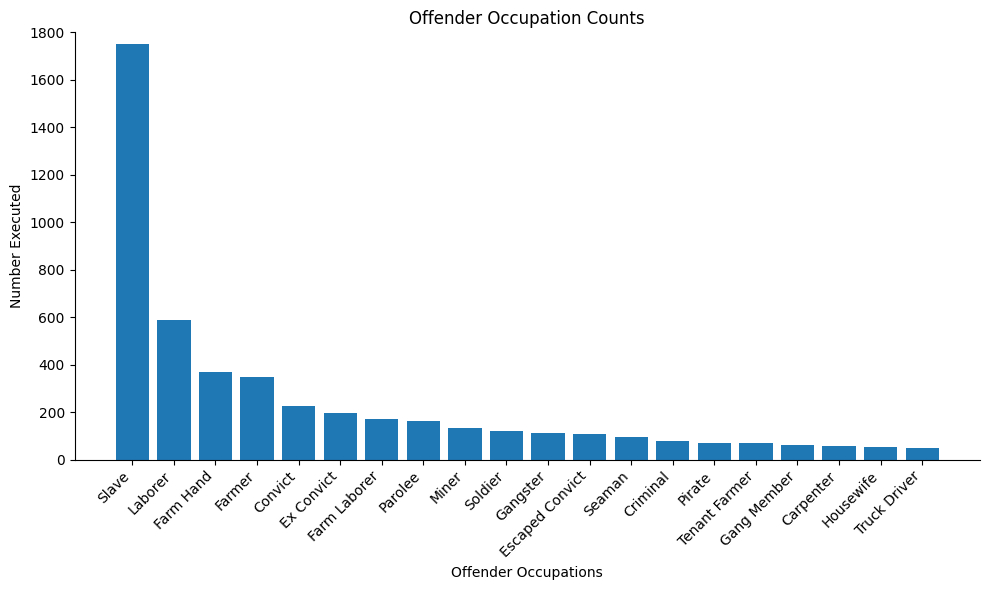

In [ ]:
off_occ_top_20 = off_occ_clean['off_occ'].value_counts().head(20)

plt.figure(figsize=(10,6))
plt.bar(off_occ_top_20.index, off_occ_top_20.values)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1800)

viz_format(title='Offender Occupation Counts', xlabel='Offender Occupations', ylabel='Number Executed')
plt.show()

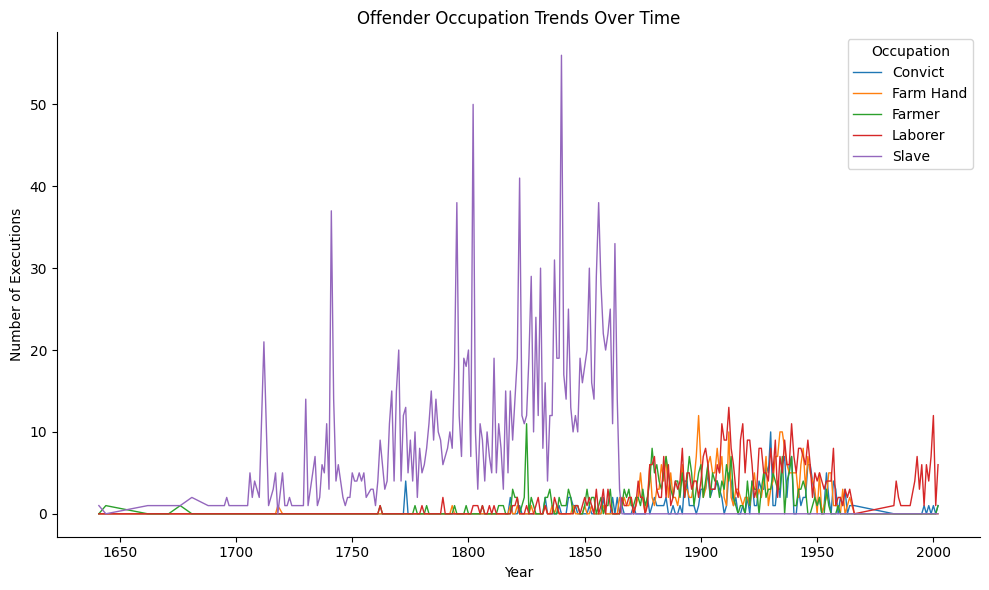

In [ ]:
off_occ_top_5 = off_occ_clean['off_occ'].value_counts().head(5)
off_occ_clean = off_occ_clean[off_occ_clean['off_occ'].isin(off_occ_top_5.index)]
occupation_trends = off_occ_clean.groupby(['date_year', 'off_occ']).size().unstack(fill_value=0).sort_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=occupation_trends, palette="tab10", linewidth=1, dashes=False)

plt.legend(title='Occupation')
viz_format(title='Offender Occupation Trends Over Time', xlabel='Year', ylabel='Number of Executions')

plt.show()

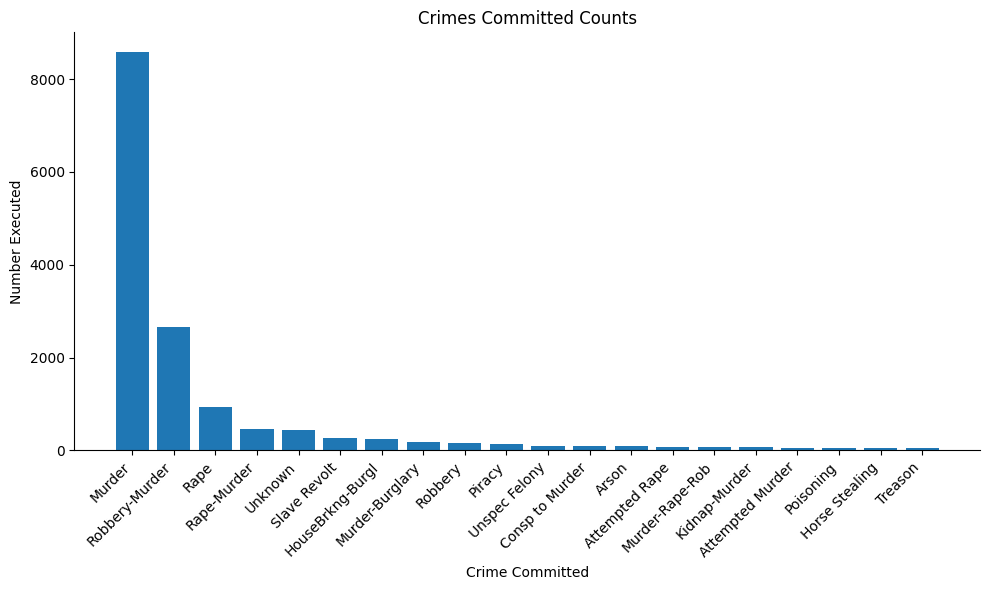

In [ ]:
crimes_committed = df_h['crime_com'].value_counts().head(20)
plt.figure(figsize=(10,6))
plt.bar(crimes_committed.index, crimes_committed.values)
plt.xticks(rotation=45, ha="right")

viz_format(title='Crimes Committed Counts', xlabel='Crime Committed', ylabel='Number Executed')
plt.show()

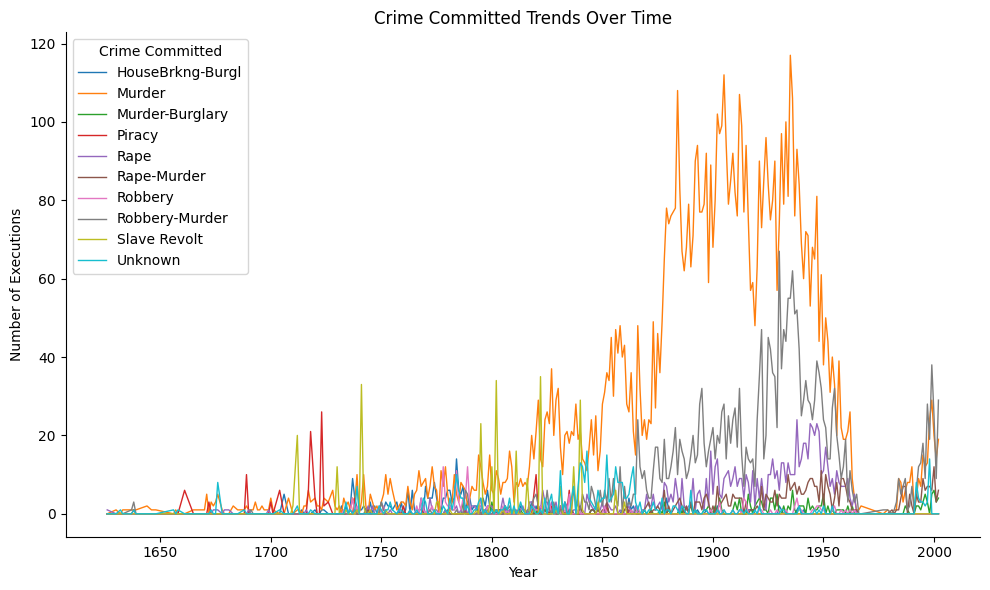

In [ ]:
crimes_committed2 = df_h['crime_com'].value_counts().head(10)
df_h2 = df_h[df_h['crime_com'].isin(crimes_committed2.index)]
crime_com_trends = df_h2.groupby(['date_year', 'crime_com']).size().unstack(fill_value=0).sort_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=crime_com_trends, palette="tab10", linewidth=1, dashes=False)

plt.legend(title='Crime Committed')
viz_format(title='Crime Committed Trends Over Time', xlabel='Year', ylabel='Number of Executions')
plt.show()

In [ ]:
conn.close()